# RAPID-MFA-19: One at a time sensitivity analysis

## Descriptions
This is a RAPID MFA one at a time sensitivity analysis to identify which input variables the model is most sensitive to.  So, it answers the question of how much the result variables changes if we change the input variables. 

The model takes three inputs:
- The DMC (Direct Material Consumption) _Inflows_ time series, in million tonnes
- The survival curve’s normal distribution _mean_ parameter
- The survival curve’s normal distribution _standard deviation_ parameter

The data and code below are the flow-driven dynamic MFA model from _Accounting for the Material Stock of Nations_ (Fishman et al. 2014). This study explores the flows and stocks of four EW-MFA material groups (timber, nonmetallic minerals, iron, and other metals) in Japan and the United States.


### Exogenous variables
__Inflows:__ Iron inflows, Japan from _Accounting for the Material Stock of Nations_ (Fishman et al. 2014)

__Survival curve:__ Fixed mean and standard deviation of iron. 


### Relations with other RAPID-MFA codes
- The concept of a flow driven model, explained in  `RAPID-MFA-1: The_flow_driven_model`. The inputus however are different.

- The code below is a basic implementation that prioritizes similarity to the dynamic MFA model equations. For faster and more efficient code implementations, check `RAPID-MFA-19:18_speeding_up_the_flow_driven_model_with_convolution`
 and `RAPID-MFA-19_speeding_up_the_stock_driven_model_with_convolution`


## Licence and how to cite
Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 

## 1. Load libraries

In [1]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Define example input data

In [2]:
# %% 2. Define example input data
# timeframes
input_data = pd.Series([5.368053963, 4.599245144, 7.778141396, 10.40946094, 8.612509432, 
                        9.294833307, 6.872771035, 6.131480153, 7.675508564, 7.656760079, 
                        22.36252695, 13.26566029, 11.57560672, 14.24030449, 15.5685982, 
                        24.43131036, 42.7792729, 44.40791736, 52.61167105, 54.0044283, 
                        73.46850832, 37.86125762, 58.92838997, 135.0291435, 100.6286295, 
                        108.3565278, 131.2462731, 275.825282, 265.5538642, 271.9214933, 
                        318.6953652, 326.4563373, 476.5492788, 498.8840475, 635.5669994, 
                        801.8130779, 724.9835985, 767.8567933, 839.4157856, 838.1205998, 
                        1074.986997, 1438.628104, 1520.676671, 1104.51503, 1406.702202, 
                        1639.535553, 1960.551947, 1934.782522, 2001.642926, 2537.560937, 
                        3616.139069, 4304.422416, 4080.048109, 3269.937006, 3777.529008, 
                        4651.528793, 1524.425, 1860.658, 2375.616, 2544.14, 2963.854, 
                        2921.764, 3031.046, 3455.525, 3950.27, 4394.143, 4745.475, 2335.772, 
                        1058.163, 1376.133, 2202.474, 3890.472, 4281.006, 6601.591, 8790.017, 
                        8322.582, 9346.699, 9762.278, 12973.309, 15083.617, 13061.982, 
                        16399.014, 21582.001, 28040.996, 30478.46654, 33467.24176, 39899.90487, 
                        41529.31669, 49219.66214, 67345.10531, 70343.66735, 81169.16776, 
                        99478.49338, 100022.4938, 97569.72846, 120035.2762, 117325.1142, 
                        107524.1067, 100916.0215, 101258.772, 88670.81072, 105325.7562, 
                        109841.3529, 101131.7817, 98431.90713, 85623.35019, 102211.4884, 
                        98970.74956, 92814.95999, 95673.05432, 114501.5443, 120297.8667, 
                        122051.1472, 125109.1653, 103498.3784, 101174.942, 102470.2093, 
                        110436.7953, 106498.5484, 111751.7779, 97191.76952, 95048.03814, 
                        108624.3669, 96888.54608, 92999.7933, 98879.84507, 101041.9843, 
                        101680.7382, 101843.3801, 101837.002, 101799.5306, 101730.1686, 
                        101629.7132, 101498.9618, 101337.9144, 101144.9763, 100921.7422, 
                        100667.4148, 100382.7914, 100067.0746, 99721.85899, 99347.94188, 
                        98946.12051, 98517.98941, 98065.1431, 97589.97339, 97094.07479, 
                        96577.44732, 96043.28002, 95490.77564, 94923.12322, 94339.52552, 
                        93742.37432, 93130.87235, 92508.20868, 91872.78878, 91227.00443, 
                        90570.85565, 89905.93695, 89232.24835, 88550.5871, 87864.14226, 
                        87171.3193, 86475.30728, 85776.90347, 85077.7024, 84378.50133, 
                        83680.89478, 82984.88277, 82288.07349, 81591.26421, 80895.25219, 
                        80199.24018
                       ], 
                        name = 'inflows',
                        index = [1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 
                                 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 
                                 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 
                                 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 
                                 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 
                                 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 
                                 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 
                                 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 
                                 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 
                                 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 
                                 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 
                                 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 
                                 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 
                                 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 
                                 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 
                                 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 
                                 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 
                                 2048, 2049, 2050

                         ]
)  # Iron inflows per year in Japan

#Parameters for the survival curve
ages = range(0, len(input_data))  # the maximum age in the MFA model is equal to the length of the input data
mean = 50
std_dev = 16.66666667 

## 3. Flow driven model as function

The flow driven model is written in a *Function* to be able to call and run the same inflow driven DMFA model as often as required. The *Function* needs the input data, ages, mean and the standard deviation as defined earlier and returns the full DMFA system.

In [3]:
# %% 3. Flow driven MFA in function
def flow_driven_model(input_data, ages, mean, std_dev):

    survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev) 
    mfa_system = {}
    timeframes = cohorts = input_data.index  

    time_interval = 1 # Interval between timeframes, usually 1, e.g. from 2005 to 2006 but can be different, e.g. 2005 to 2010. In which case time_interval = 5

    cohort_stop = (cohorts[-1] + time_interval)

    survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

    mfa_system = pd.DataFrame(index = timeframes, columns = ['stocks', 
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])    
    mfa_system['inflows'] = input_data

    # and populate that matrix
    for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
        survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]
    
    # initialize the cohort_survival_matrix filled with zeros
    cohorts_survival_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

    # And populate it
    for cohort in cohorts:
        # scale the shifted survival curve with the inflow of the time-th timeframe
        cohorts_survival_matrix.loc[:, cohort] = survival_curves_matrix.loc[:, cohort] * mfa_system['inflows'].loc[cohort]

    mfa_system["stocks"] = cohorts_survival_matrix.sum(axis='columns')
    mfa_system["stocks"]

    mfa_system["stock_changes"] = np.diff(mfa_system["stocks"], prepend=0)
    mfa_system["stock_changes"]

    mfa_system["outflows"] = mfa_system["inflows"] - mfa_system["stock_changes"]
    mfa_system["outflows"]

    return mfa_system

## 4. View the full MFA system

In [4]:
#Call function to show the original run
mfa_system = flow_driven_model(input_data, ages, mean, std_dev)

In [5]:
# Set up the MFA system
units = {'time_interval': 'year', 
         'flows':         'kg/year', 
         'stocks':        'kg'}

# Add units to the MFA system
mfa_system_with_units = mfa_system.rename(columns={"stocks" : 'stocks [' + units['stocks'] + ']', 
                                                   "inflows" : 'inflows [' + units['flows'] + ']', 
                                                   "outflows" : 'outflows [' + units['flows'] + ']', 
                                                   "stock_changes" : 'stock_changes [' + units['flows'] + ']'})

<Axes: ylabel='kg/year'>

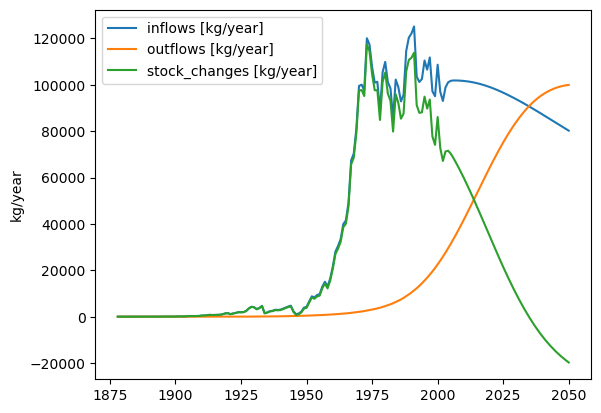

In [6]:
#plot the original run
mfa_system_with_units[["inflows [kg/year]", "outflows [kg/year]", "stock_changes [kg/year]"]].plot(ylabel=units['flows'])

## 5. Sensitivity runs
In the following code, the inflow, the mean and the standard deviation are changed one by one to calculate the sensitivity of the calculated results

In [7]:
#Increase input parameter by 10%
Increase = 1.1 #Decrease of 10% increase

#Decrease input parameter by 10% 
Decrease = 0.9 #Decrease of 10% in inflows

Run the function for each parameter with increased and decreased values

In [ ]:
# Run the function with increased values
mfa_inflow_increase = flow_driven_model(input_data * Increase, ages, mean, std_dev)
mfa_mean_increase = flow_driven_model(input_data, ages, mean * Increase, std_dev)
mfa_std_increase = flow_driven_model(input_data, ages, mean, std_dev * Increase)

# Run the function with decreased values
mfa_inflow_decrease = flow_driven_model(input_data * Decrease, ages, mean, std_dev)
mfa_mean_decrease = flow_driven_model(input_data, ages, mean * Decrease, std_dev)
mfa_std_decrease = flow_driven_model(input_data, ages, mean, std_dev * Decrease)

Add all model results in one dataframe

In [9]:
#Add columns to identify scenario
mfa_system["scenario"] = "original"
mfa_inflow_increase["scenario"] = "inflow +10%"
mfa_mean_increase["scenario"]   = "mean +10%"
mfa_std_increase["scenario"]    = "std +10%"
mfa_inflow_decrease["scenario"] = "inflow -10%"
mfa_mean_decrease["scenario"]   = "mean -10%"
mfa_std_decrease["scenario"]    = "std -10%"

#Create one df with the previous index as a column
for df in [
    mfa_system,
    mfa_inflow_increase,
    mfa_mean_increase,
    mfa_std_increase,
    mfa_inflow_decrease,
    mfa_mean_decrease,
    mfa_std_decrease
]:
    df["year"] = df.index

# Concat all dataframes into a single one
mfa_all = pd.concat([
    mfa_system,
    mfa_inflow_increase,
    mfa_mean_increase,
    mfa_std_increase,
    mfa_inflow_decrease,
    mfa_mean_decrease,
    mfa_std_decrease
], axis=0, ignore_index=True)

## 6. View the newly calculated model results

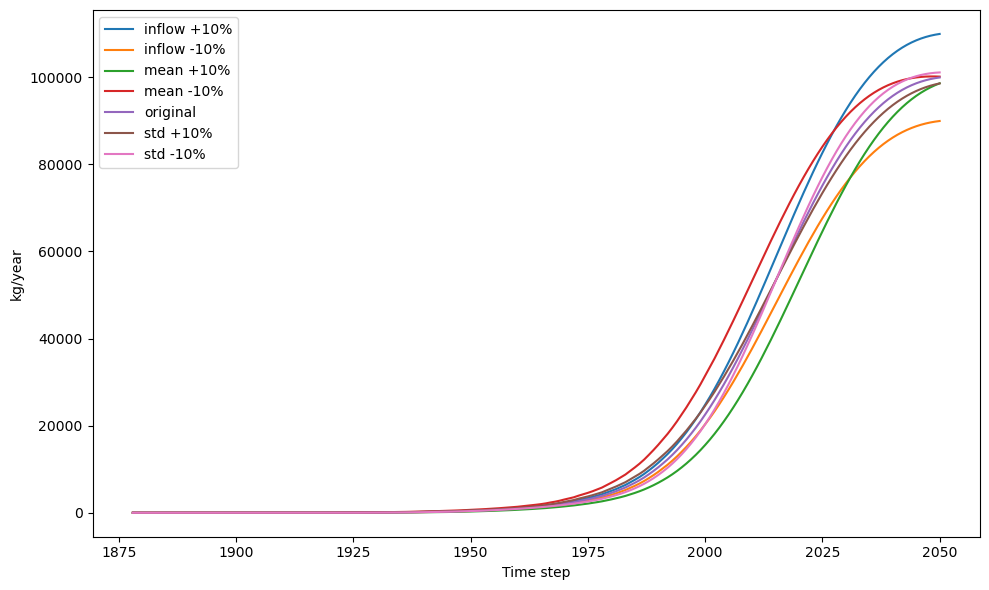

In [10]:
#visualise the result - for outflows
plt.figure(figsize=(10, 6))

for scenario, group in mfa_all.groupby("scenario"):
    plt.plot(mfa_system.index, group["outflows"].values, label=scenario)

plt.xlabel("Time step")
plt.ylabel("kg/year")
plt.legend()
plt.tight_layout()
plt.show()

### 6.1 Visualisations

Now we can calculate percent change from the original results:

$ percent\_change = \frac{new\_result - original\_result}{original\_result} $


In [11]:
#identify the baseline
baseline = (
    mfa_all[mfa_all["scenario"] == "original"]
    .set_index("year")[["stocks", "inflows", "outflows", "stock_changes"]]
)

#add baseline into dataframe
merged_mfa_all = mfa_all.merge(
    baseline,
    on="year",
    suffixes=("", "_baseline")
)

# Calculate the percentual changes
for col in ["stocks", "inflows", "outflows", "stock_changes"]:
    merged_mfa_all[col + "_pct_change"] = (
        (merged_mfa_all[col] - merged_mfa_all[col + "_baseline"]) / merged_mfa_all[col + "_baseline"] * 100
    )

#select the value of choice
selection = ["outflows_pct_change"] 

#Merge all into one dataframe
sensitivity_percent_change = (
    merged_mfa_all
    .pivot(index="year", columns="scenario", values=selection)
)


Plot the results

<Figure size 600x700 with 0 Axes>

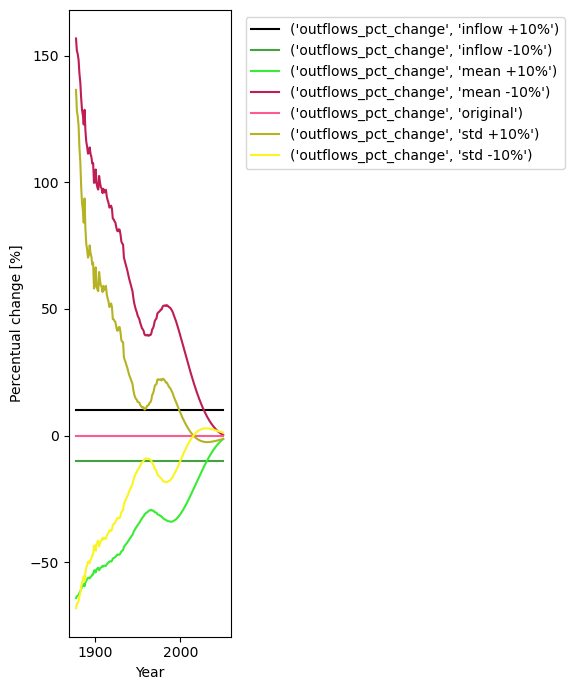

In [12]:
#Plot selection of choice in percentual change
plt.figure(figsize=(6, 7))

sensitivity_percent_change.plot(
    legend=False,
    figsize=(6, 7),
    color=[
        '#000000', 
        "#44A242", "#37EC34", 
        "#BE1D55", "#FF5993", 
        "#B5B224", "#F9F521",
        "#3572BD", "#529BF5"
    ]
)

plt.xlabel("Year")
plt.ylabel("Percentual change [%]")

plt.legend(
    sensitivity_percent_change.columns,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()
